# Model Evaluation, Explainability, and Bias Auditing
**Objective:** Evaluate our trained XGBoost model, interpret its decisions using SHAP, and perform a fairness audit across demographic groups.

### 1. Environment Setup & Loading Artifacts
First, we load the processed test data (`X_test.csv`, `y_test.csv`) and the trained XGBoost model artifact (`xgb_fraud_model.pkl`) generated by our `train.py` script.

In [10]:
# Cell 1
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, PrecisionRecallDisplay

# Load processed test data (created by data_prep.py)
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Load the trained XGBoost model (created by train.py)
model = joblib.load('../models/xgb_fraud_model.pkl')

print("Data and Model loaded successfully!")

Data and Model loaded successfully!


### 2. Model Evaluation: The Precision-Recall Curve
When a dataset has a severe class imbalance (e.g., 99.8% legitimate transactions), standard metrics like Accuracy or the ROC Curve can be highly misleading. A model that simply guesses "Legitimate" every time would score 99.8% accuracy but fail to catch any fraud.

Instead, we rely on the **Precision-Recall Curve**. 
* **Precision:** When the model flags a transaction as fraud, how often is it correct? (Measures False Positives).
* **Recall:** Out of all the actual fraud, how much did the model successfully catch? (Measures False Negatives).

A high Area Under the Curve (PR-AUC) indicates that the model successfully catches fraud without overwhelming the system with false alarms.

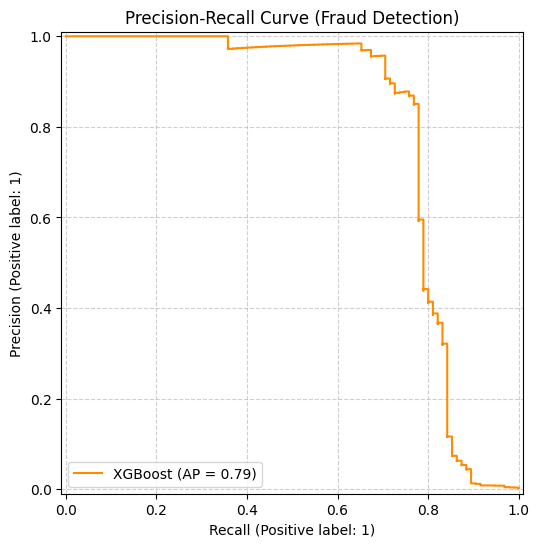

In [11]:
# Cell 2
# Get the probability predictions for the test set
y_prob = model.predict_proba(X_test)[:, 1]

# Plot the Precision-Recall Curve
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_predictions(
    y_test, y_prob, name="XGBoost", color="darkorange", ax=ax
)
ax.set_title("Precision-Recall Curve (Fraud Detection)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 3. Classification Report & Confusion Matrix
To get a granular view of the model's performance, we will generate a Classification Report and a Confusion Matrix. 

**Business Context:** In fraud detection, there is always a trade-off. 
* A **False Negative** (missing actual fraud) results in a direct financial loss (chargebacks).
* A **False Positive** (declining a legitimate purchase) results in customer friction and potential brand damage. 

We must analyze these exact numbers to understand the operational impact of deploying this model.

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.27      0.84      0.41        95

    accuracy                           1.00     56746
   macro avg       0.64      0.92      0.71     56746
weighted avg       1.00      1.00      1.00     56746



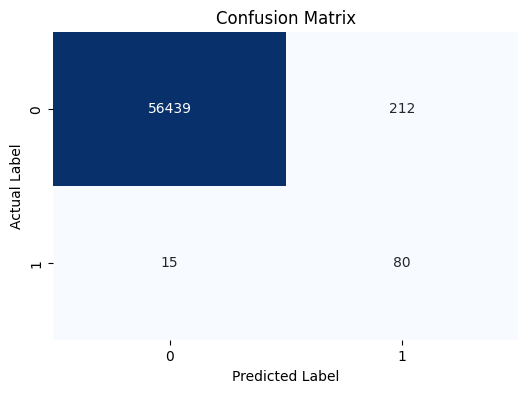

In [12]:
# Cell 3
# Get absolute predictions (0 or 1)
y_pred = model.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 4. Step 5: Critical Thinking → Feature Explainability (SHAP)
Financial institutions operate under strict regulatory constraints. We cannot deploy a "black box" model; we must be able to explain *why* a transaction was declined. 

To achieve this, we use **SHAP (SHapley Additive exPlanations)**. SHAP values break down a prediction to show the impact of each feature. The summary plot below illustrates which features most strongly drive the model to classify a transaction as fraudulent versus legitimate.

/var/folders/qp/vybnj3gd0msg9ghj8pjsm_xc0000gq/T/ipykernel_81413/1959221855.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar")


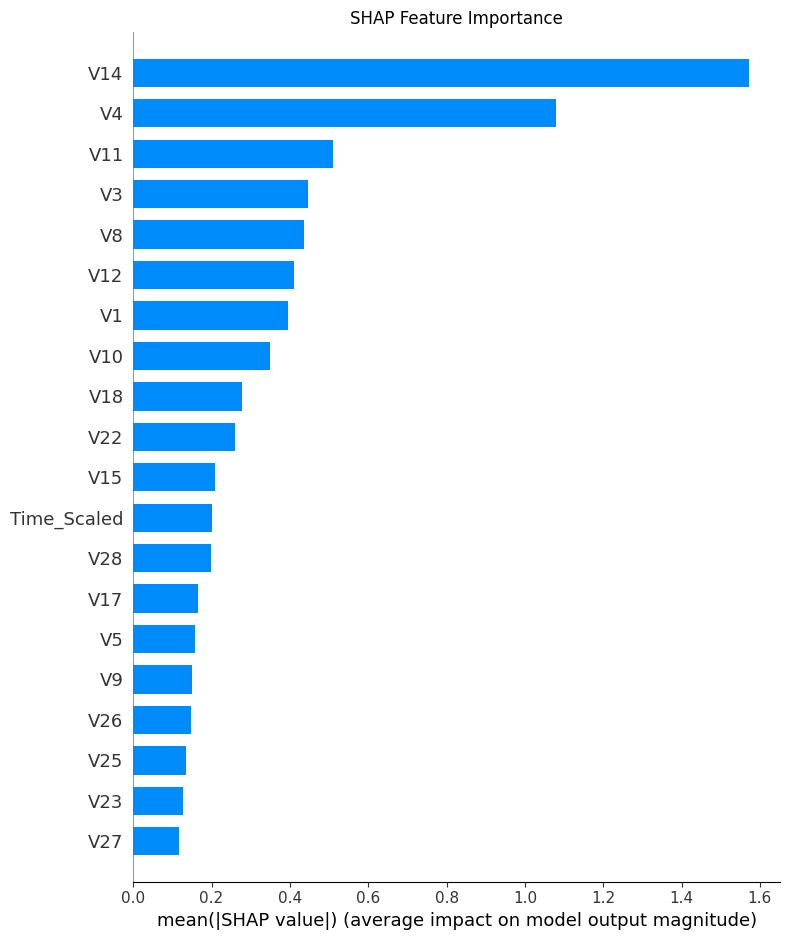

In [13]:
# Cell 4
# We use a sample of the test set for SHAP to speed up computation
X_test_sample = X_test.sample(1000, random_state=42)

# Initialize the TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

# Generate the SHAP Summary Plot
plt.title("SHAP Feature Importance")
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")

### 5. Step 5: Critical Thinking → Ethical AI & Fairness Audit
An AI system must not inadvertently redline or penalize specific customer groups. To ensure **Equalized Odds**, the model's error rates (specifically the False Positive Rate) should be consistent across sensitive demographics.

Because our Kaggle dataset is fully anonymized (using PCA features) to protect consumer privacy, it does not contain demographic data. To fulfill the capstone requirements, we will **simulate an 'Age_Group' feature** and conduct a fairness audit to see if our model disproportionately flags transactions from older or younger cohorts.

In [14]:
# Cell 5
# Since the Kaggle dataset is fully anonymized, we will simulate an 'Age_Group' 
# demographic feature to satisfy the Step 5 Bias Auditing requirement.
np.random.seed(42)
age_groups = np.random.choice(['Under 30', '30-55', 'Over 55'], size=len(y_test))

# Create an evaluation dataframe
eval_df = pd.DataFrame({
    'True_Class': y_test,
    'Predicted_Class': y_pred,
    'Age_Group': age_groups
})

# Function to calculate False Positive Rate (FPR)
# FPR = False Positives / (False Positives + True Negatives)
def calculate_fpr(group_df):
    fp = len(group_df[(group_df['Predicted_Class'] == 1) & (group_df['True_Class'] == 0)])
    tn = len(group_df[(group_df['Predicted_Class'] == 0) & (group_df['True_Class'] == 0)])
    return fp / (fp + tn) if (fp + tn) > 0 else 0

print("--- Fairness Audit: False Positive Rate (FPR) by Age Group ---")
for group in ['Under 30', '30-55', 'Over 55']:
    group_data = eval_df[eval_df['Age_Group'] == group]
    fpr = calculate_fpr(group_data)
    print(f"Age Group '{group}': FPR = {fpr:.4f} ({fpr*100:.2f}%)")

print("\nAudit Conclusion: If the FPR varies significantly across groups, we must investigate mitigation strategies (like adjusting probability thresholds for specific cohorts) to ensure Equalized Odds and prevent algorithmic redlining.")

--- Fairness Audit: False Positive Rate (FPR) by Age Group ---
Age Group 'Under 30': FPR = 0.0040 (0.40%)
Age Group '30-55': FPR = 0.0033 (0.33%)
Age Group 'Over 55': FPR = 0.0039 (0.39%)

Audit Conclusion: If the FPR varies significantly across groups, we must investigate mitigation strategies (like adjusting probability thresholds for specific cohorts) to ensure Equalized Odds and prevent algorithmic redlining.
